# Product Sales Prediction - Linear Regression - Gradient Decent




## Agenda

| # | Phase | Nội dung chính |
|---|-------|----------------|
| 1 | [Business Problem & Data & EDA](#Phase-1-—-Chuẩn-bị-dữ-liệu) | Định nghĩa bài toán, khám phá và kiểm tra dữ liệu |
| 2 | [Feature Engineering](#Phase-2-—-Tiền-xử-lý-dữ-liệu-(Feature-Engineering)) | Chuẩn hóa features, chiến lược scaling |
| 3 | [Model Definition](#Phase-3-—-Định-nghĩa-mô-hình) | Xây dựng Linear Regression & metrics từ đầu |
| 4 | [Model Training](#Phase-4-—-Huấn-luyện-mô-hình) | Gradient descent, hyperparameters, loss curve |
| 5 | [Evaluation & Report](#Phase-5-—-Đánh-giá-&-Báo-cáo-kết-quả) | Metrics, phân tích kết quả, kết luận |


In [15]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [16]:
# LOAD DATASET

train_df = pd.read_csv("retail_train_80_before_scale.csv")
test_df = pd.read_csv("retail_test_20_before_scale.csv")

print("Original shapes:", train_df.shape, test_df.shape)

# Scale unit_price, qty_roll_mean_30d bằng scaler.pkl (giống LinearRegression.ipynb)
print("[INFO] Loading scaler.pkl...")
scaler = joblib.load("scaler.pkl")

numeric_features = ["unit_price", "qty_roll_mean_30d"]

train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[numeric_features] = scaler.transform(train_df_scaled[numeric_features])
test_df_scaled[numeric_features] = scaler.transform(test_df_scaled[numeric_features])

train_df = train_df_scaled
test_df = test_df_scaled

train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

print("Shapes after scaling + dropna:", train_df.shape, test_df.shape)
train_df.head()

Original shapes: (96000, 80) (24000, 80)
[INFO] Loading scaler.pkl...
Shapes after scaling + dropna: (96000, 80) (24000, 80)


/Users/hoangphuc.nguyen/Desktop/ML_Practice2/.venv/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,transaction_year,transaction_month,transaction_day,transaction_dayofweek,qty_roll_mean_30d,customer_gender_Female,...,payment_method_Gift Card,payment_method_PayPal,sales_channel_In-Store,sales_channel_Mobile App,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West
0,-0.345401,20,5.032527,4,2024,1,1,0,0.136990,0,...,0,0,1,0,0,0,0,1,0,0
1,0.543162,0,5.773277,3,2024,1,1,0,-0.017313,0,...,0,0,0,0,1,0,1,0,0,0
2,-1.280785,0,3.995445,3,2024,1,1,0,0.113202,0,...,0,0,0,1,0,0,1,0,0,0
3,-1.280785,0,3.995445,1,2024,1,1,0,0.113202,0,...,1,0,0,1,0,0,0,1,0,0
4,0.998194,0,5.961675,0,2024,1,1,0,-0.085984,1,...,0,0,1,0,0,1,0,0,0,0


In [17]:
# DATA VALIDATION - Kiểm tra dữ liệu phù hợp yêu cầu đề bài

print("=" * 70)
print("DATA VALIDATION")
print("=" * 70)

# 2.1 Kiểm tra cấu trúc dữ liệu
print("\n2.1 CẤU TRÚC DỮ LIỆU:")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns ({len(train_df.columns)}): {list(train_df.columns)}")

# 2.2 Kiểm tra missing values
print("\n2.2 MISSING VALUES:")
train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()
print(f"Train missing: {train_missing.sum()} (tổng)")
print(f"Test missing: {test_missing.sum()} (tổng)")
if train_missing.sum() > 0:
    print("Train missing per column:")
    print(train_missing[train_missing > 0])

# 2.3 Kiểm tra target variable
print("\n2.3 TARGET VARIABLE:")
target = "sales_amount_log"
if target in train_df.columns:
    print(f"✓ Target '{target}' có tồn tại")
    print(f"  Range: [{train_df[target].min():.4f}, {train_df[target].max():.4f}]")
    print(f"  Mean: {train_df[target].mean():.4f}, Std: {train_df[target].std():.4f}")
else:
    print(f"✗ Target '{target}' KHÔNG tồn tại!")

# 2.4 Kiểm tra data types
print("\n2.4 DATA TYPES:")
print(train_df.dtypes)

# 2.5 Kiểm tra yêu cầu đề bài
print("\n2.5 KIỂM TRA YÊU CẦU ĐỀ BÀI:")
required_categories = [
    "Product information (category, price, description)",
    "Customer demographics (age, gender, location)",
    "Purchase history (previous purchases, purchase frequency)",
    "Marketing campaign data (campaigns run, ad spend)",
    "Seasonal and holiday information"
]

columns_lower = [col.lower() for col in train_df.columns]
print(f"Tổng features: {len(train_df.columns) - 1}")

for category in required_categories:
    print(f"  • {category}")

print("\n  Feature samples có liên quan:")
for col in train_df.columns:
    if col != target:
        print(f"    - {col}")

# 2.6 Kiểm tra outliers (IQR method)
print("\n2.6 OUTLIERS CHECK (numeric columns):")
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
outlier_count = 0
for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train_df[col] < (Q1 - 1.5 * IQR)) | 
                (train_df[col] > (Q3 + 1.5 * IQR))).sum()
    if outliers > 0:
        print(f"  {col}: {outliers} outliers")
        outlier_count += outliers

if outlier_count == 0:
    print("  Không phát hiện outliers (IQR method)")

print("\n" + "=" * 70)
print("KẾT LUẬN: Dữ liệu đã sẵn sàng cho Linear Regression training")
print("=" * 70)

DATA VALIDATION

2.1 CẤU TRÚC DỮ LIỆU:
Train shape: (96000, 80)
Test shape: (24000, 80)

Columns (80): ['unit_price', 'discount_pct', 'sales_amount_log', 'customer_age_group_encoded', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_dayofweek', 'qty_roll_mean_30d', 'customer_gender_Female', 'customer_gender_Male', 'customer_gender_Other', 'customer_segment_Loyal', 'customer_segment_New', 'customer_segment_Returning', 'customer_segment_VIP', 'product_name_Bedsheet', 'product_name_Bluetooth Speaker', 'product_name_Board Game', 'product_name_Bread', 'product_name_Building Blocks', 'product_name_Cereal', 'product_name_Children Book', 'product_name_Coffee', 'product_name_Cookbook', 'product_name_Cookware Set', 'product_name_Doll', 'product_name_Dress', 'product_name_Dumbbells', 'product_name_Football', 'product_name_Headphones', 'product_name_Jacket', 'product_name_Jeans', 'product_name_Lamp', 'product_name_Laptop', 'product_name_Lipstick', 'product_name_Milk', 'prod

## [PHASE 2: DATA PREPROCESSING]
- Data Preparation
- Feature Scaling (`scaler.pkl` + z-score cho GD)

In [18]:
# 1. DATA PREPARATION: tách X, y và convert sang numpy array

target = "sales_amount_log"
feature_names = train_df.drop(columns=[target]).columns

X_train = train_df[feature_names].values.astype(float)
y_train = train_df[target].values.astype(float)

X_test = test_df.reindex(columns=feature_names).values.astype(float)
y_test = test_df[target].values.astype(float)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (96000, 79), y_train: (96000,)
X_test:  (24000, 79),  y_test:  (24000,)


In [19]:
# 2. FEATURE SCALING cho Gradient Descent
# unit_price, qty_roll_mean_30d đã được scale bằng scaler.pkl khi load dữ liệu
# GD cần z-score thêm các continuous features còn lại; giữ nguyên one-hot (0/1)

continuous_features = [
    "discount_pct",
    "transaction_year", "transaction_month", "transaction_day", "transaction_dayofweek",
    "customer_age_group_encoded",
]

X_mean = np.zeros(len(feature_names))
X_std = np.ones(len(feature_names))

for i, col in enumerate(feature_names):
    if col in continuous_features:
        X_mean[i] = np.mean(X_train[:, i])
        X_std[i] = np.std(X_train[:, i])

X_train = (X_train - X_mean) / (X_std + 1e-8)
X_test = (X_test - X_mean) / (X_std + 1e-8)

print("✓ Pre-scaled via scaler.pkl: unit_price, qty_roll_mean_30d")
print(f"✓ Z-scored {len(continuous_features)} continuous features for GD")
print(f"✓ Preserved {len(feature_names) - len(continuous_features) - 2} one-hot features")
print(f"✓ Max |X_train| after scaling: {np.max(np.abs(X_train)):.4f}")

✓ Pre-scaled via scaler.pkl: unit_price, qty_roll_mean_30d
✓ Z-scored 6 continuous features for GD
✓ Preserved 71 one-hot features
✓ Max |X_train| after scaling: 8.4947


## Phase 3 — Định nghĩa mô hình & hàm đánh giá


In [20]:
# 1. Custom Linear Regression

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=750):
        self.lr = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape #Lấy kích thước
        # Khởi tạo trọng số
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias

            error = y_pred - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss) #lưu để vẽ biểu đồ

            if epoch % 20 == 0:
                print(
                    f"Epoch {epoch:4d} | MSE = {loss:.6f}"
                )

    def predict(self, X):
        return (np.dot(X, self.weights) + self.bias) #CT Linear Regression

In [21]:
# 2. Evaluation Metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

## Phase 4 — Huấn luyện mô hình



In [22]:
# Train Model

model = LinearRegression(learning_rate=0.1,epochs=300)

print("Training...")

model.fit(X_train, y_train)

Training...
Epoch    0 | MSE = 31.333997
Epoch   20 | MSE = 0.354126
Epoch   40 | MSE = 0.346160
Epoch   60 | MSE = 0.340974
Epoch   80 | MSE = 0.336996
Epoch  100 | MSE = 0.333797
Epoch  120 | MSE = 0.331180
Epoch  140 | MSE = 0.329026
Epoch  160 | MSE = 0.327248
Epoch  180 | MSE = 0.325779
Epoch  200 | MSE = 0.324564
Epoch  220 | MSE = 0.323559
Epoch  240 | MSE = 0.322726
Epoch  260 | MSE = 0.322036
Epoch  280 | MSE = 0.321463


## Phase 5 — Đánh giá & Báo cáo kết quả


In [23]:
# Step 5.1 - Prediction: Dùng trọng số đã học để dự đoán dữ liệu mới
predictions = model.predict(X_test)

In [24]:
# Step 5.1.1 - Save test labels and predictions to a new file
# Giữ nguyên file retail_test_20.csv và tạo file mới với 2 cột cuối cùng

test_df_out = test_df.copy()
test_df_out = test_df_out.drop(columns=["y_test", "y_pred"], errors="ignore")
test_df_out["y_test"] = y_test
test_df_out["y_pred"] = predictions

output_file = "retail_test_20_with_predictions.csv"
test_df_out.to_csv(output_file, index=False)
print(f"Saved {len(test_df_out)} rows to {output_file} with y_test and y_pred columns")

Saved 24000 rows to retail_test_20_with_predictions.csv with y_test and y_pred columns


In [25]:
# Step 5.2 - Evaluation Results
train_predictions = model.predict(X_train)

results = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R² train",
        "R² test"
    ],
    "Value": [
        mse(y_test, predictions),
        rmse(y_test, predictions),
        mae(y_test, predictions),
        r2_score(y_train, train_predictions),
        r2_score(y_test, predictions)
    ]
})

results

,Metric,Value
0,MSE,0.322268
1,RMSE,0.567686
2,MAE,0.460472
3,R² train,0.696449
4,R² test,0.694934


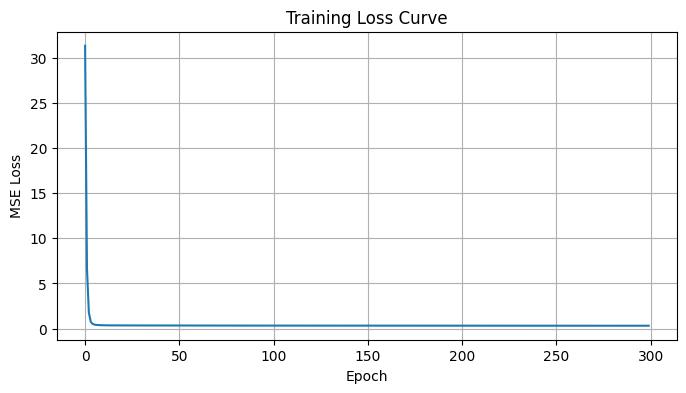

In [26]:
# Step 5.3 - Training Loss Curve

plt.figure(figsize=(8,4))

plt.plot(model.loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

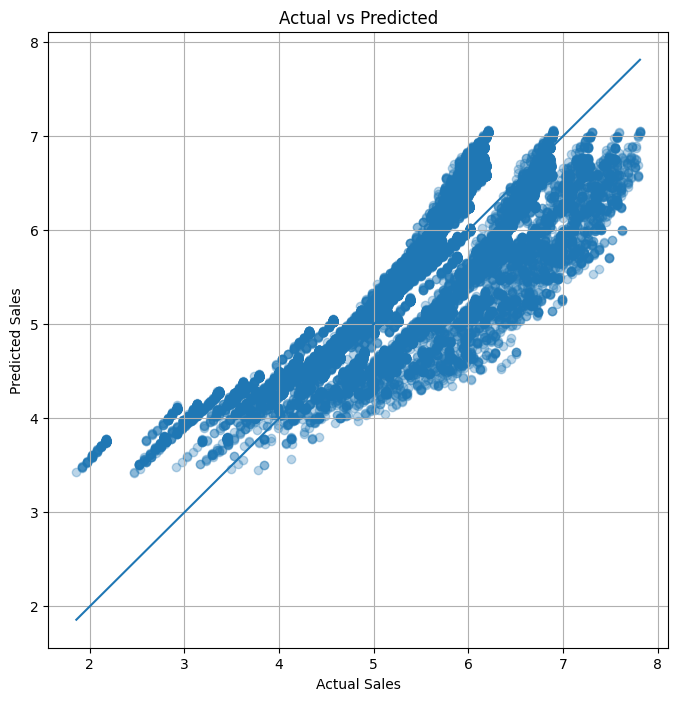

In [27]:
# Step 5.4 - Actual vs Predicted

# Đường vẽ lý tưởng: y = x
# Nếu điểm nằm sát đường này => dự đoán tốt
plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

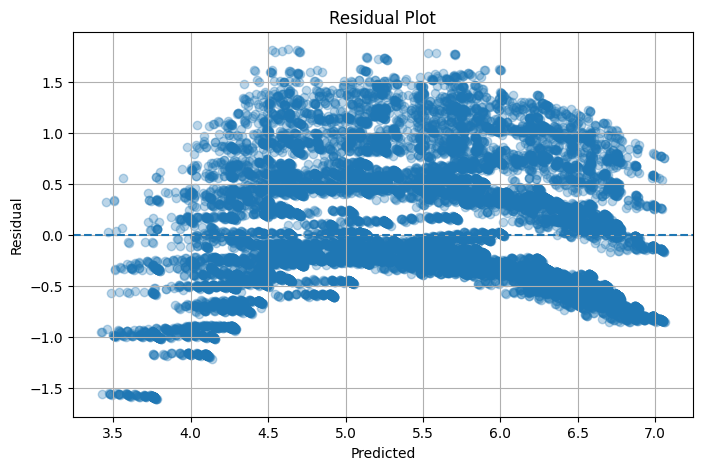

In [28]:
# Step 5.5 - Residual Plot
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter( predictions, residuals, alpha=0.3)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()